In [47]:
import os
from pathlib import Path

import clickhouse_connect
import matplotlib.pyplot as plt
import polars as pl
from dotenv import load_dotenv

ENV_PATH = Path.cwd().parent / ".env"

load_dotenv(ENV_PATH)

clickhouse_host = "localhost"
clickhouse_port = int(os.getenv("CLICKHOUSE_PORT", "8123"))
clickhouse_user = os.getenv("CLICKHOUSE_USER", "minimarket_user")
clickhouse_password = os.getenv("CLICKHOUSE_PASSWORD", "minimarket_password")
clickhouse_db = os.getenv("CLICKHOUSE_DB", "minimarket")
print(f"Connecting to ClickHouse at {clickhouse_host}:{clickhouse_port} with user {clickhouse_user} and database {clickhouse_db}")


Connecting to ClickHouse at localhost:8123 with user clickhouse and database minimarket


In [48]:
client = clickhouse_connect.get_client(
    host=clickhouse_host,
    port=clickhouse_port,
    username=clickhouse_user,
    password=clickhouse_password,
    database=clickhouse_db,
)


def query_to_polars(sql: str) -> pl.DataFrame:
    result = client.query(sql)

    return pl.DataFrame(
        result.result_rows,
        schema=result.column_names,
        orient="row",
    )

In [44]:
tables = query_to_polars("""
    show tables
""")

tables

name
str
"""dim_customer"""
"""dim_date"""
"""dim_product"""
"""fact_sales"""
"""raw_customers"""
…
"""raw_transactions"""
"""stg_customers"""
"""stg_products"""


In [53]:
fact_sales_count = query_to_polars("""
    select count(*) as row_count
    from fact_sales
""")

fact_sales_count

row_count
i64
2382


## Q1. Top 5 Products per Categories
**NOTE THAT THE DATA THAT IS BEING USE IS FOR PRESENTATION PURPOSE ONLY AND DOES NOT REPRESENT REAL WORLD PRODUCTS OR SALES**

This Q1 section will answer which products that is the top 5 Products in terms of total sales in each Categories.
To help understand this code I have made 5 categories (Beverages, Dairy, Instant Noodles, Personal Care, and Snacks) for this case. 
I wrote the query from the mart table "fact_sales" and joined it with the "dim_product", because the The query uses `fact_sales` joined with `dim_product`, because product category and product name are stored in the product dimension and the total quantity of the sales are from fact sales. From my data generator, it will always show a maximum of 5 products in each categories, this will represent how my code is able to show this Q1 Question.


In [52]:
top_products = query_to_polars("""
    with product_sales as (
        select
            dp.category,
            dp.product_name,
            sum(fs.quantity) as total_quantity
        from fact_sales fs
        inner join dim_product dp
            on fs.product_key = dp.product_key
        group by
            dp.category,
            dp.product_name
    ),

    ranked as (
        select
            category,
            product_name,
            total_quantity,
            row_number() over (
                partition by category
                order by total_quantity desc
            ) as product_rank
        from product_sales
    )

    select
        category,
        product_name,
        total_quantity
    from ranked
    where product_rank <= 5
    order by
        category,
        total_quantity desc
""")

top_products

category,product_name,total_quantity
str,str,i64
"""Beverage""","""Aqua 600ml Variant 41""",100
"""Beverage""","""Aqua 600ml Variant 31""",98
"""Beverage""","""Aqua 600ml Variant 1""",98
"""Beverage""","""Aqua 600ml Variant 21""",96
"""Beverage""","""Aqua 600ml Variant 11""",96
…,…,…
"""Snack""","""Pepsodent 75g Variant 47""",177
"""Snack""","""Pepsodent 75g Variant 37""",177
"""Snack""","""Pepsodent 75g Variant 27""",174


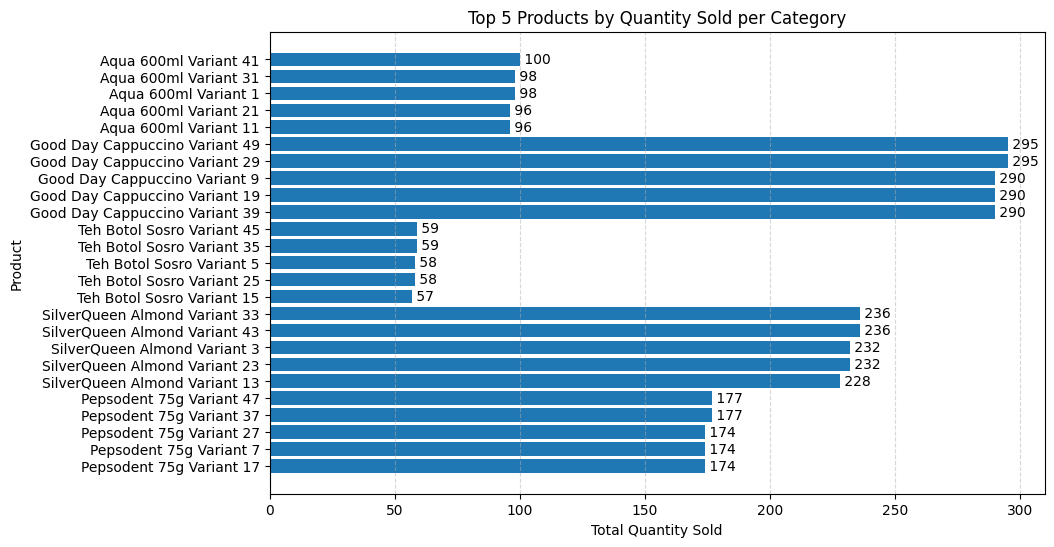

In [57]:
import matplotlib.pyplot as plt

products = top_products["product_name"].to_list()
quantities = top_products["total_quantity"].to_list()

plt.figure(figsize=(10, 6))

bars = plt.barh(products, quantities)

plt.xlabel("Total Quantity Sold")
plt.ylabel("Product")
plt.title("Top 5 Products by Quantity Sold per Category")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f" {int(width)}",
        va="center",
    )

plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.gca().invert_yaxis()
plt.show()

## Conclusion Q1
The models from my data mart is sufficient to show this chart. Why is that? because we have the product names from "dim_product" that holds every product that the minimarket is selling, while the "fact_sales" holds every sales history for each product. Join those two tables and add a ranking query based on "total_quantity" of sales then we have our Top 5 Products By Quantity Sold Per Category. "***Title Drop***!"

## Q2.Sales Trend (Line Graph)
**NOTE THAT THE DATA THAT IS BEING USE IS FOR PRESENTATION PURPOSE ONLY AND DOES NOT REPRESENT REAL WORLD PRODUCTS OR SALES**

This section will show and explain the sales trend for our own minimarket — mostly my minimarket. This graph will be shown in a line graph. Why? Because it will tangibly represent the sales trend and the viewer can see easily compare the sales for each respective month.

First of all, the query will get the years, and months details from "dim_date", then the total revenue from summing the subtotal of the "fact_sales". Because we are dividing it by months, the query will grouped up based on the year, month and month_name then order it by year and month. This will show the sales trend that is acceptable to answer the Q2 Question.

In [30]:
monthly_revenue = query_to_polars("""
    select
        dd.year,
        dd.month,
        dd.month_name,
        sum(fs.subtotal) as total_revenue
    from fact_sales fs
    inner join dim_date dd
        on fs.date_key = dd.date_key
    group by
        dd.year,
        dd.month,
        dd.month_name
    order by
        dd.year,
        dd.month
""")

monthly_revenue

year,month,month_name,total_revenue
i64,i64,str,"decimal[*,2]"
2026,1,"""January""",15968638.25
2026,2,"""February""",15384953.25
2026,3,"""March""",16249734.25
2026,4,"""April""",14889166.25
2026,5,"""May""",13258282.75
2026,6,"""June""",13273648.25


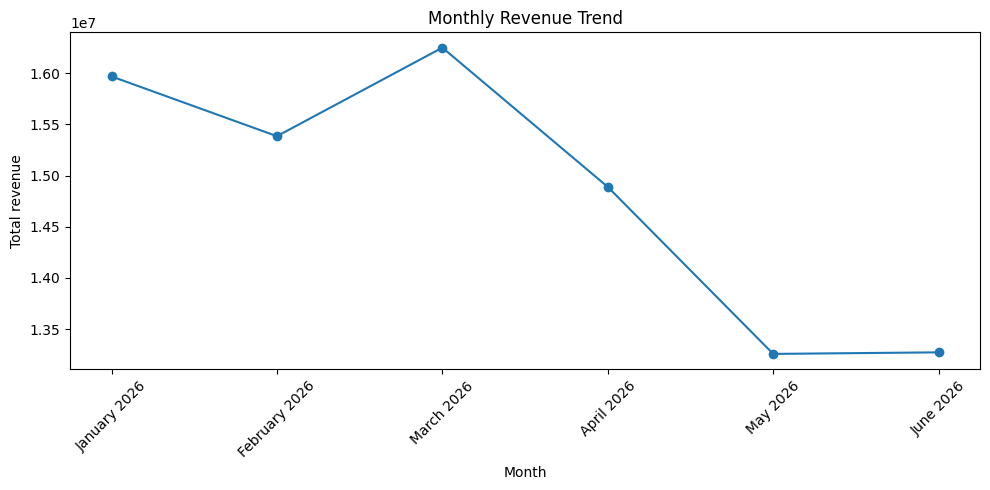

In [31]:
monthly_revenue_plot = monthly_revenue.with_columns(
    (
        pl.col("month_name") + " " + pl.col("year").cast(pl.Utf8)
    ).alias("month_label")
)

x_labels = monthly_revenue_plot["month_label"].to_list()
revenues = monthly_revenue_plot["total_revenue"].to_list()

plt.figure(figsize=(10, 5))
plt.plot(x_labels, revenues, marker="o")
plt.xlabel("Month")
plt.ylabel("Total revenue")
plt.title("Monthly Revenue Trend")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The query and the line graphs correctly represent the revenue based on their months. 

## Q3 -- Payment Method (PIE CHART)

This section will be presented in a pie chart that illustrates the payment methods distribution percentage or "market share" — if you want to be fancy about it. The query extracts payment methods, total transactions count, and the distribution percentage of each payment method from "fact_sales". Then it will be grouped by payment method and ordered by total transaction counts. Using a pie chart is useful because it makes the distribution of payment methods easy to understand as part of the whole picture.


In [ ]:
payment_distribution = query_to_polars("""
    select
        payment_method,
        count(distinct transaction_id) as transaction_count,
        round(
            count(distinct transaction_id) * 100.0
            / sum(count(distinct transaction_id)) over (),
            2
        ) as percentage
    from fact_sales
    group by payment_method
    order by transaction_count desc
""")

payment_distribution

payment_method,transaction_count,percentage
str,i64,f64
"""e-wallet""",243,26.3
"""credit""",243,26.3
"""debit""",243,26.3
"""cash""",195,21.1


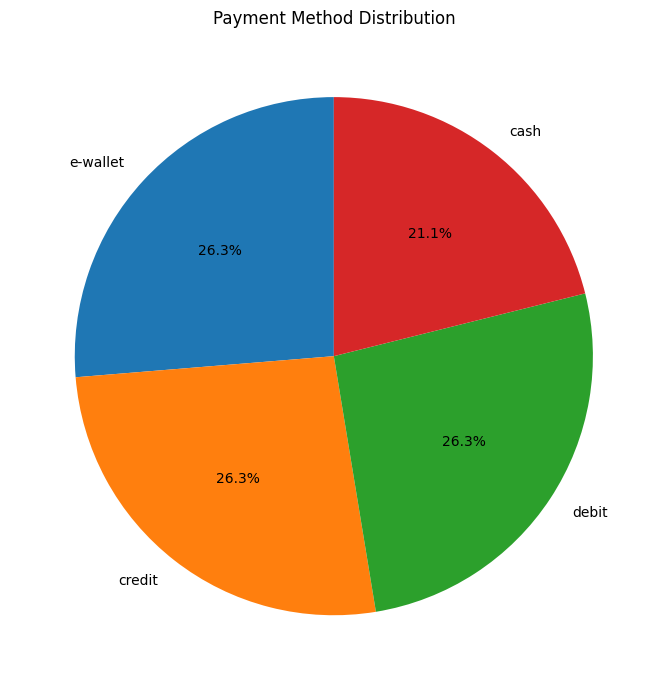

In [ ]:
labels = payment_distribution["payment_method"].to_list()
values = payment_distribution["transaction_count"].to_list()

plt.figure(figsize=(7, 7))
plt.pie(
    values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
)
plt.title("Payment Method Distribution")
plt.tight_layout()
plt.show()